# Float model initialization and training

In [1]:
%matplotlib inline
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

ModuleNotFoundError: No module named 'matplotlib'

In [27]:
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        return x

In [28]:
model = MNISTModel().to(device)

total = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total}')
print(model)


Total parameters: 118282
MNISTModel(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [29]:
tf = transforms.Compose([
    transforms.ToTensor(),                                # [0,1]
    transforms.Normalize(mean=0.5, std=0.5),              # -> [-1, 1]
    transforms.Lambda(lambda x: x.view(784).t()),      # (784, 1)
])

train = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=tf)
test  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=tf)

trainloader = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True)
testloader  = torch.utils.data.DataLoader(test,  batch_size=128, shuffle=False)


for x, y in trainloader:
    x, y = x.to(device), y.to(device)
    print(x.shape)
    print(y.shape)
    print(model(x).shape)
    break

torch.Size([128, 784])
torch.Size([128])
torch.Size([128, 10])


In [30]:
num_epochs = 0
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

best_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running = 0.0
    for i, (x, y) in enumerate(trainloader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item()
        if i % 100 == 99:
            print(f'[ep {epoch+1} batch {i+1}] loss {running/100:.3f}')
            running = 0.0

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in testloader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(-1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
    acc = 100 * correct / total
    print(f'epoch {epoch+1}: acc {acc:.2f}%, best acc {best_acc:.2f}%')
    
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), 'mlp_model.pth')
        print(f'Saved best model with acc {best_acc:.2f}%')

In [31]:
model.load_state_dict(torch.load('best_mlp_model.pth'))
model.eval()

correct = total = 0
with torch.no_grad():
    for x, y in testloader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(-1)
        correct += (pred == y).sum().item()
        total   += y.size(0)
print(f'Acc {100*correct/total:.2f}%')

# Acc 98.06%

Acc 98.06%


# Quantization

In [32]:
from typing import Dict, List, Optional, Tuple


def quantize_tensor(tensor: torch.Tensor,
                    num_bits: int = 8,
                    scale: Optional[float] = None,
                    zero_point: Optional[int] = None,
                    signed: bool = False,
                    symmetric: bool = False):
    """Quantizes a tensor to a specified number of bits with optional scale and zero point."""

    qmin = -2 ** (num_bits - 1) if signed else 0
    qmax = 2 ** (num_bits - 1) - 1 if signed else 2 ** num_bits - 1

    if scale is None:
        if symmetric:
            max_val = tensor.abs().max()
            scale = max_val / qmax if max_val > 0 else 1.0
        else:
            min_val, max_val = tensor.min(), tensor.max()
            scale = (max_val - min_val) / (qmax - qmin) if max_val > min_val else 1.0
    if zero_point is None:
        if symmetric:
            zero_point = 0
        else:
            min_val = tensor.min()
            zero_point = int(round(qmin - min_val / scale))
            zero_point = max(qmin, min(qmax, zero_point))
    
    quantized = torch.clamp((tensor / scale).round() + zero_point, qmin, qmax).to(torch.int32)
    return quantized, scale, zero_point

def dequantize_tensor(quantized: torch.Tensor, scale: float, zero_point: int):
    """Dequantizes a quantized tensor back to floating point."""
    return (quantized.float() - zero_point) * scale

In [33]:
class Observer:
    """Observer for collecting statistics needed for quantization."""
    def __init__(self,
                 num_bits: int = 8,
                 signed: bool = False,
                 symmetric: bool = False):
        self.min_val = float('inf')
        self.max_val = float('-inf')
        self.num_bits = num_bits
        self.signed = signed
        self.symmetric = symmetric

    def observe(self, tensor: torch.Tensor):
        """Update min and max values based on the observed tensor."""
        self.min_val = min(self.min_val, tensor.min().item())
        self.max_val = max(self.max_val, tensor.max().item())

    def get_stats(self):
        """Return the collected min and max values."""
        return self.min_val, self.max_val
    
    def get_scale_zero_point(self):
        """Calculate scale and zero point based on collected statistics."""
        min_val, max_val = self.get_stats()
        qmin = -2 ** (self.num_bits - 1) if self.signed else 0
        qmax = 2 ** (self.num_bits - 1) - 1 if self.signed else 2 ** self.num_bits - 1

        if self.symmetric:
            max_abs = max(abs(min_val), abs(max_val))
            scale = max_abs / qmax if max_abs > 0 else 1.0
            zero_point = 0
        else:
            scale = (max_val - min_val) / (qmax - qmin) if max_val > min_val else 1.0
            zero_point = int(round(qmin - min_val / scale))
            zero_point = max(qmin, min(qmax, zero_point))

        return scale, zero_point
    
    def reset(self):
        """Reset the collected statistics."""
        self.min_val = float('inf')
        self.max_val = float('-inf')

    def quantize(self, tensor: torch.Tensor):
        """Quantize a tensor using the collected statistics."""
        scale, zero_point = self.get_scale_zero_point()
        return quantize_tensor(tensor, self.num_bits, scale, zero_point, self.signed, self.symmetric)
    
    def dequantize(self, quantized: torch.Tensor, scale: float, zero_point: int):
        """Dequantize a tensor using the provided scale and zero point."""
        return dequantize_tensor(quantized, scale, zero_point)

In [34]:
# ── Helpers ────────────────────────────────────────────────────────────────────

def _qbounds(num_bits: int, signed: bool) -> Tuple[int, int]:
    if signed:
        return -(2 ** (num_bits - 1)), 2 ** (num_bits - 1) - 1
    return 0, 2 ** num_bits - 1


def _as_tensor(x, ref: torch.Tensor) -> torch.Tensor:
    if torch.is_tensor(x):
        return x.to(device=ref.device, dtype=ref.dtype)
    return torch.as_tensor(x, device=ref.device, dtype=ref.dtype)


def _quantize(tensor: torch.Tensor, scale, zp,
              num_bits: int, signed: bool) -> torch.Tensor:
    qmin, qmax = _qbounds(num_bits, signed)
    scale = _as_tensor(scale, tensor)
    zp    = _as_tensor(zp,    tensor)
    # round-half-up (matches (x + 1<<(sh-1)) >> sh on FPGA)
    q = torch.floor(tensor / scale + 0.5) + zp
    return torch.clamp(q, qmin, qmax).to(torch.int32)


def _dequantize(q: torch.Tensor, scale, zp) -> torch.Tensor:
    qf = q.float()
    return (qf - _as_tensor(zp, qf)) * _as_tensor(scale, qf)


def _int32_quantize(tensor: torch.Tensor, scale) -> torch.Tensor:
    """Quantize a bias into int32 using scale = x_s * w_s (zp=0)."""
    scale = _as_tensor(scale, tensor)
    q = (tensor / scale).round()
    i32min, i32max = -(2 ** 31), 2 ** 31 - 1
    return torch.clamp(q, i32min, i32max).to(torch.int32)


def _scale_zp(tensor: torch.Tensor, num_bits: int,
              signed: bool, symmetric: bool) -> Tuple[float, int]:
    """Per-tensor (scale, zero-point) for the chosen signed/symmetric mode."""
    qmin, qmax = _qbounds(num_bits, signed)
    if symmetric:
        max_abs = float(tensor.abs().max().item())
        # symmetric range is min(|qmin|, qmax) so int8 stays in [-127, 127]
        bound = min(abs(qmin), qmax) if signed else qmax
        scale = (max_abs / bound) if max_abs > 0 else 1.0
        zp    = 0 if signed else (qmin + qmax + 1) // 2
        return scale, zp
    max_val = float(tensor.max().item())
    min_val = float(tensor.min().item())
    if max_val > min_val:
        scale = (max_val - min_val) / (qmax - qmin)
    else:
        scale = 1.0
    zp = int(round(qmin - min_val / scale))
    return scale, zp


def _quantize_w(tensor: torch.Tensor, num_bits: int,
                signed: bool, symmetric: bool):
    """Per-tensor weight quantize honoring (signed, symmetric). Returns (q, s, zp)."""
    s, zp = _scale_zp(tensor, num_bits, signed, symmetric)
    qmin, qmax = _qbounds(num_bits, signed)
    q = torch.clamp((tensor / s).round() + zp, qmin, qmax).to(torch.int32)
    return q, s, zp


# ── Legacy symmetric-only shims (kept for any external callers) ───────────────

def _symmetric_scale(tensor: torch.Tensor, num_bits: int) -> float:
    _, qmax = _qbounds(num_bits, signed=True)
    max_abs = float(tensor.abs().max().item())
    return (max_abs / qmax) if max_abs > 0 else 1.0


def _symmetric_quantize(tensor: torch.Tensor, scale: float,
                        num_bits: int) -> torch.Tensor:
    qmin, qmax = _qbounds(num_bits, signed=True)
    return torch.clamp((tensor / scale).round(), qmin, qmax).to(torch.int32)


In [35]:
# ── RELU LUT ───────────────────────────────────────────────────────────────────

def build_relu_lut(obs_in: 'Observer', obs_out: 'Observer',
                   in_bits: int = 8, out_bits: int = 8,
                   signed: bool = True) -> torch.Tensor:
    """1-D int32 LUT of length 2^in_bits: quantized RELU mapping.

    Address range follows the *input* (ssm_out) bit width / sign.
    Stored values follow the *output* (gelu_out) bit width / sign.
    On FPGA: addr = y_ssm_q - QMIN_in, data = gelu_out_q (BRAM ROM).
    """
    qmin_in,  qmax_in  = _qbounds(in_bits,  signed)
    s_in,  zp_in  = obs_in.get_scale_zero_point()
    s_out, zp_out = obs_out.get_scale_zero_point()

    codes   = torch.arange(qmin_in, qmax_in + 1, dtype=torch.float32)
    x_float = (codes - zp_in) * s_in
    y_float = F.relu(x_float)
    y_q     = _quantize(y_float, s_out, zp_out, out_bits, signed)
    return y_q


# ── Quantized linear: int32 bias + precomputed scalar M ────────────────────────

def quant_linear(x_q:    torch.Tensor, x_zp: int,
                 w_q:    torch.Tensor, w_zp: int,    # subtract w_zp before MAC
                 bias_q: torch.Tensor,                # int32, scale = x_s * w_s
                 M:      float,                       # (x_s * w_s) / out_s
                 out_zp: int,
                 num_bits: int = 8,                   # OUTPUT bit width
                 signed:   bool = True) -> torch.Tensor:
    """Integer MAC + int32 bias + rescale by scalar M.

    `num_bits` controls the *output* clamp range. Input/weight bit widths are
    implicit in the integer values themselves and don't affect the int32 MAC.

    On FPGA:
        acc[o] = Σ_i (x_q[i] - x_zp) * (w_q[o,i] - w_zp)   # int32 accumulator
        acc[o] += bias_q[o]                                # int32 add
        y_q[o] = clamp(round(acc[o] * M) + out_zp)         # M is fixed-point shift
    """
    qmin, qmax = _qbounds(num_bits, signed)

    x_c = x_q.float() - float(x_zp)
    w_c = w_q.float() - float(w_zp)
    acc = x_c @ w_c.T                      # (B, out)
    acc = acc + bias_q.float()             # int32 bias add
    y   = acc * float(M)                   # scalar requant multiplier
    return torch.clamp(torch.floor(y + 0.5) + out_zp, qmin, qmax).to(torch.int32)

In [36]:
class QuantizedMNISTModel(nn.Module):
    """Quantized MLP with ReLU implemented as `max(x_q, zp_in)`.

    Because ReLU is a per-element clamp to the input's zero-point, the ReLU
    output reuses its input's (scale, zero_point) — no requantize, no LUT. On
    FPGA this collapses to a single comparator per element. The cost is
    resolution: values below `zp_in` are all mapped to `zp_in`, so the usable
    quantization range for the post-ReLU tensor is effectively [zp_in, qmax].
    """
    def __init__(self,
                 model: 'MNISTModel',
                 bits,
                 signed: bool = False,
                 symmetric: bool = False):
        super().__init__()

        self.signed = signed
        self.symmetric = symmetric
        self._fm = model

        self.bits_cfg = self._normalize_bits(bits)

        self._build_observers()
        self.qparams: Optional[Dict] = None

    # ── Bit-width resolver ────────────────────────────────────────────────────

    @staticmethod
    def _normalize_bits(bits) -> Dict:
        if isinstance(bits, int):
            return {'default': bits}
        if isinstance(bits, dict):
            cfg = dict(bits)
            cfg.setdefault('default', 8)
            return cfg
        raise TypeError(f"bits must be int or dict, got {type(bits).__name__}")

    def _bits(self, kind: str) -> int:
        return self.bits_cfg.get(kind, self.bits_cfg['default'])

    # ── Observers ─────────────────────────────────────────────────────────────

    def _build_observers(self):
        s, sym = self.signed, self.symmetric
        b = self._bits

        # No separate observers for ReLU outputs: they share the preceding
        # FC layer's (scale, zero_point).
        self.obs_in  = Observer(b('in_b'),      signed=s, symmetric=sym)
        self.obs_fc1 = Observer(b('fc1_out_b'), signed=s, symmetric=sym)
        self.obs_fc2 = Observer(b('fc2_out_b'), signed=s, symmetric=sym)
        self.obs_out = Observer(b('out_b'),     signed=s, symmetric=sym)

    @torch.no_grad()
    def calibrate(self, dataloader, device: str = 'cpu', max_batches: int = 50):
        m = self._fm.to(device).eval()

        batch_idx = 0
        for batch_idx, batch in enumerate(dataloader):
            if batch_idx >= max_batches:
                break

            u = (batch[0] if isinstance(batch, (list, tuple)) else batch).to(device)

            self.obs_in.observe(u)
            u = m.fc1(u);  self.obs_fc1.observe(u)
            u = F.relu(u)                       # ReLU output shares fc1 (s, zp)
            u = m.fc2(u);  self.obs_fc2.observe(u)
            u = F.relu(u)                       # ReLU output shares fc2 (s, zp)
            u = m.fc3(u);  self.obs_out.observe(u)

        print(f"[calibrate] done – {min(batch_idx + 1, max_batches)} batches observed")

    # ── Build quantized params ────────────────────────────────────────────────

    @torch.no_grad()
    def build_quantized_params(self):
        m = self._fm
        s, sym = self.signed, self.symmetric
        b = self._bits

        def quant_w(t: torch.Tensor, nb: int):
            return _quantize_w(t, nb, s, sym)

        p: Dict = {}

        # ── Activation scales / zero-points ──
        p['in_s'],  p['in_zp']  = self.obs_in.get_scale_zero_point()
        p['fc1_s'], p['fc1_zp'] = self.obs_fc1.get_scale_zero_point()
        p['fc2_s'], p['fc2_zp'] = self.obs_fc2.get_scale_zero_point()
        p['out_s'], p['out_zp'] = self.obs_out.get_scale_zero_point()

        p['in_bits']      = b('in_b')
        p['fc1_out_bits'] = b('fc1_out_b')
        p['fc2_out_bits'] = b('fc2_out_b')
        p['out_bits']     = b('out_b')

        # ── FC1 (input: raw image) ──
        fc1_w_bits = b('fc1_w_b')
        fc1_w_q, fc1_w_s, fc1_w_zp = quant_w(m.fc1.weight.data, fc1_w_bits)
        p['fc1_w']      = fc1_w_q
        p['fc1_w_s']    = fc1_w_s
        p['fc1_w_zp']   = fc1_w_zp
        p['fc1_w_bits'] = fc1_w_bits
        p['fc1_b_q']    = _int32_quantize(m.fc1.bias.data, p['in_s'] * fc1_w_s)
        p['fc1_M']      = (p['in_s'] * fc1_w_s) / p['fc1_s']

        # ── FC2 (input: ReLU(fc1) → shares fc1's s, zp) ──
        fc2_w_bits = b('fc2_w_b')
        fc2_w_q, fc2_w_s, fc2_w_zp = quant_w(m.fc2.weight.data, fc2_w_bits)
        p['fc2_w']      = fc2_w_q
        p['fc2_w_s']    = fc2_w_s
        p['fc2_w_zp']   = fc2_w_zp
        p['fc2_w_bits'] = fc2_w_bits
        p['fc2_b_q']    = _int32_quantize(m.fc2.bias.data, p['fc1_s'] * fc2_w_s)
        p['fc2_M']      = (p['fc1_s'] * fc2_w_s) / p['fc2_s']

        # ── FC3 (input: ReLU(fc2) → shares fc2's s, zp) ──
        fc3_w_bits = b('fc3_w_b')
        fc3_w_q, fc3_w_s, fc3_w_zp = quant_w(m.fc3.weight.data, fc3_w_bits)
        p['fc3_w']      = fc3_w_q
        p['fc3_w_s']    = fc3_w_s
        p['fc3_w_zp']   = fc3_w_zp
        p['fc3_w_bits'] = fc3_w_bits
        p['fc3_b_q']    = _int32_quantize(m.fc3.bias.data, p['fc2_s'] * fc3_w_s)
        p['fc3_M']      = (p['fc2_s'] * fc3_w_s) / p['out_s']

        self.qparams = p

        print(f"[build] quant ready (signed={s}, symmetric={sym}); "
              f"fc1_w={fc1_w_bits}, fc2_w={fc2_w_bits}, fc3_w={fc3_w_bits}, "
              f"in={p['in_bits']}, fc1={p['fc1_out_bits']}, "
              f"fc2={p['fc2_out_bits']}, out={p['out_bits']} "
              f"(ReLU = max(x_q, zp_in), no LUT)")

    # ── Integer forward ───────────────────────────────────────────────────────

    @staticmethod
    def _relu_q(x_q: torch.Tensor, zp: int) -> torch.Tensor:
        # Hardware equivalent: y = (x_q > zp) ? x_q : zp   (one comparator).
        return torch.clamp(x_q, min=int(zp))

    @torch.no_grad()
    def forward_quantized(self, u: torch.Tensor) -> torch.Tensor:
        assert self.qparams is not None, "Run calibrate() + build_quantized_params() first"
        p = self.qparams
        s = self.signed
        dev = u.device

        u_q = _quantize(u, p['in_s'], p['in_zp'], p['in_bits'], signed=s)

        fc1_q = quant_linear(
            u_q, p['in_zp'],
            p['fc1_w'].to(dev), p['fc1_w_zp'],
            p['fc1_b_q'].to(dev),
            p['fc1_M'], p['fc1_zp'],
            num_bits=p['fc1_out_bits'], signed=s,
        )

        relu1_q = self._relu_q(fc1_q, p['fc1_zp'])

        fc2_q = quant_linear(
            relu1_q, p['fc1_zp'],                  # ReLU reuses fc1's zp
            p['fc2_w'].to(dev), p['fc2_w_zp'],
            p['fc2_b_q'].to(dev),
            p['fc2_M'], p['fc2_zp'],
            num_bits=p['fc2_out_bits'], signed=s,
        )

        relu2_q = self._relu_q(fc2_q, p['fc2_zp'])

        out_q = quant_linear(
            relu2_q, p['fc2_zp'],                  # ReLU reuses fc2's zp
            p['fc3_w'].to(dev), p['fc3_w_zp'],
            p['fc3_b_q'].to(dev),
            p['fc3_M'], p['out_zp'],
            num_bits=p['out_bits'], signed=s,
        )

        return _dequantize(out_q, p['out_s'], p['out_zp'])

    def forward(self, u: torch.Tensor) -> torch.Tensor:
        return self.forward_quantized(u)

    # ── FPGA export ───────────────────────────────────────────────────────────

    @torch.no_grad()
    def export_fpga_params(self, path: str):
        assert self.qparams is not None, \
            "Run calibrate() + build_quantized_params() first"

        p = self.qparams
        out = {}

        def arr(t):
            return t.cpu().numpy() if isinstance(t, torch.Tensor) else np.array(t)

        out['signed']    = np.array(self.signed)
        out['symmetric'] = np.array(self.symmetric)

        # ── Input activation ──
        out['in_s']    = arr(p['in_s'])
        out['in_zp']   = arr(p['in_zp'])
        out['in_bits'] = arr(p['in_bits'])

        # ── FC1 ──
        out['fc1_w']        = arr(p['fc1_w'])
        out['fc1_w_s']      = arr(p['fc1_w_s'])
        out['fc1_w_zp']     = arr(p['fc1_w_zp'])
        out['fc1_w_bits']   = arr(p['fc1_w_bits'])
        out['fc1_b_q']      = arr(p['fc1_b_q'])
        out['fc1_M']        = arr(p['fc1_M'])
        out['fc1_s']        = arr(p['fc1_s'])
        out['fc1_zp']       = arr(p['fc1_zp'])          # ← also the ReLU1 threshold
        out['fc1_out_bits'] = arr(p['fc1_out_bits'])

        # ── FC2 (input is ReLU(fc1); ReLU = max(x, fc1_zp)) ──
        out['fc2_w']        = arr(p['fc2_w'])
        out['fc2_w_s']      = arr(p['fc2_w_s'])
        out['fc2_w_zp']     = arr(p['fc2_w_zp'])
        out['fc2_w_bits']   = arr(p['fc2_w_bits'])
        out['fc2_b_q']      = arr(p['fc2_b_q'])
        out['fc2_M']        = arr(p['fc2_M'])
        out['fc2_s']        = arr(p['fc2_s'])
        out['fc2_zp']       = arr(p['fc2_zp'])          # ← also the ReLU2 threshold
        out['fc2_out_bits'] = arr(p['fc2_out_bits'])

        # ── FC3 (input is ReLU(fc2); ReLU = max(x, fc2_zp)) ──
        out['fc3_w']      = arr(p['fc3_w'])
        out['fc3_w_s']    = arr(p['fc3_w_s'])
        out['fc3_w_zp']   = arr(p['fc3_w_zp'])
        out['fc3_w_bits'] = arr(p['fc3_w_bits'])
        out['fc3_b_q']    = arr(p['fc3_b_q'])
        out['fc3_M']      = arr(p['fc3_M'])
        out['out_s']      = arr(p['out_s'])
        out['out_zp']     = arr(p['out_zp'])
        out['out_bits']   = arr(p['out_bits'])

        np.savez_compressed(path, **out)
        print(f"[export] saved {len(out)} arrays → {path}")

In [37]:
bits = {
    'default':        8,   # fallback for anything not listed

    # ── Activations ──
    # ReLU uses its input's (s, zp), so there are no separate relu_out bits.
    'in_b':           8,   # input image (after Normalize/view)
    'fc1_out_b':      8,   # fc1 pre-activation; ReLU1 output shares this
    'fc2_out_b':      8,   # fc2 pre-activation; ReLU2 output shares this
    'out_b':          8,   # fc3 logits (final output)

    # ── Weights ──
    'fc1_w_b':        8,   # (784, 128)
    'fc2_w_b':        8,   # (128, 128)
    'fc3_w_b':        8,   # (128, 10)
}

qm = QuantizedMNISTModel(model, bits=bits, signed=False, symmetric=False)
qm.calibrate(trainloader, device=device, max_batches=100)
qm.build_quantized_params()

qm.export_fpga_params('quantized_mlp_params.npz')

[calibrate] done – 100 batches observed
[build] quant ready (signed=False, symmetric=False); fc1_w=8, fc2_w=8, fc3_w=8, in=8, fc1=8, fc2=8, out=8 (ReLU = max(x_q, zp_in), no LUT)
[export] saved 32 arrays → quantized_mlp_params.npz


In [38]:
qm.eval().to(device)
correct = 0
total = 0
with torch.no_grad():
    for x, y in testloader:
        x, y = x.to(device), y.to(device)
        logits = qm.forward_quantized(x)   # integer scan + float decoder
        pred = logits.argmax(-1)
        correct += (pred == y).sum().item()
        total   += y.size(0)
print(f'Quantize model acc: {100*correct/total:.2f}%')

Quantize model acc: 98.02%


# How it works on FPGA

In [39]:
quantized_params = np.load("quantized_mlp_params.npz")

print("All quantized parameter keys:", list(quantized_params.keys()))

signed = quantized_params['signed']
symmetric = quantized_params['symmetric']
print(f"Quantization scheme - Signed: {signed}, Symmetric: {symmetric}")

All quantized parameter keys: ['signed', 'symmetric', 'in_s', 'in_zp', 'in_bits', 'fc1_w', 'fc1_w_s', 'fc1_w_zp', 'fc1_w_bits', 'fc1_b_q', 'fc1_M', 'fc1_s', 'fc1_zp', 'fc1_out_bits', 'fc2_w', 'fc2_w_s', 'fc2_w_zp', 'fc2_w_bits', 'fc2_b_q', 'fc2_M', 'fc2_s', 'fc2_zp', 'fc2_out_bits', 'fc3_w', 'fc3_w_s', 'fc3_w_zp', 'fc3_w_bits', 'fc3_b_q', 'fc3_M', 'out_s', 'out_zp', 'out_bits']
Quantization scheme - Signed: False, Symmetric: False


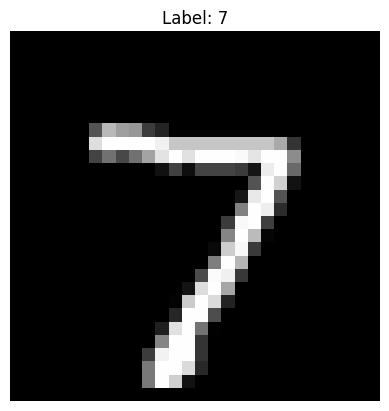

In [40]:
# take simple image from mnist
import matplotlib.pyplot as plt
import numpy as np

tf = transforms.Compose([
    transforms.ToTensor(),                                # [0,1]
    transforms.Normalize(mean=0.5, std=0.5),              # -> [-1, 1]
    transforms.Lambda(lambda x: x.view(784).t()),         # (784, 1)
])

test  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=tf)
testloader  = torch.utils.data.DataLoader(test,  batch_size=1, shuffle=False)

x, label = testloader.dataset[0]

# convert to numpy array and back from 784 -> 28x28 for visualization
img = x.numpy().reshape(28, 28)

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f'Label: {label}')
plt.axis('off')
plt.show()

# add batch dimension and move to device
x = x.unsqueeze(0).to(device)  


if bool(np.asarray(symmetric).item()):
    qtf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: torch.clamp((x * 255.0 - 128.0).round(), -128, 127).to(torch.int32)),
        transforms.Lambda(lambda x: x.view(784).t()),
    ])
else:
    qtf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: torch.clamp((x * 255.0).round(), 0, 255).to(torch.int32)),
        transforms.Lambda(lambda x: x.view(784).t()),
    ])

qtest  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=qtf)
qtestloader  = torch.utils.data.DataLoader(qtest,  batch_size=1, shuffle=False)

In [41]:
# helper function to change float scale to int scale with shift

def compute_int_scale(scale: float, bits: int = 31) -> tuple[int, int]:
    """
    Approximate 1/scale as (M_int >> shift).
    bits: precision of M_int (default 31 → fits in int32 without sign issues)
    """
    inv = 1.0 / scale
    shift = bits - int(np.floor(np.log2(inv))) - 1
    M_int = int(round(inv * (2 ** shift)))
    return M_int, shift

def quantize_fpga(x: np.ndarray,
                  M: int, C: int, shift: int, zero_point: int,
                  num_bits: int, signed: bool) -> np.ndarray:
    qmin = -(2 ** (num_bits - 1))     if signed else 0
    qmax =  (2 ** (num_bits - 1) - 1) if signed else (2 ** num_bits - 1)
    acc = x.astype(np.int64) * M - C                # one int64 MAC
    y   = acc  >> shift
    return np.clip(y + zero_point, qmin, qmax).astype(np.int32)

def quant_linear_fpga(
    x:       np.ndarray,   # (B, C_in)  int32
    x_zp:    int,
    w_q:     np.ndarray,   # (C_out, C_in) int32, already zero-point subtracted
    b_q:     np.ndarray,   # (C_out,)      int32
    M_int:   int,          # integer multiplier from compute_int_scale
    shift:   int,
    out_zp:  int,
    num_bits: int,
    signed:  bool,
) -> np.ndarray:
    qmin = -(2 ** (num_bits - 1))     if signed else 0
    qmax =  (2 ** (num_bits - 1) - 1) if signed else (2 ** num_bits - 1)

    # (1) subtract input zero-point and widen to int64 to avoid overflow
    x_c = x.astype(np.int64) - x_zp          # (B, C_in)

    # (2) integer MAC — weights are already zero-point-subtracted
    acc = x_c @ w_q.astype(np.int64).T       # (B, C_out)
    acc = acc + b_q.astype(np.int64)          # bias absorbed in int32 accumulator

    # (3) rescale: pure integer multiply then arithmetic right-shift
    y = (acc * M_int) >> shift

    # (4) add output zero-point and clamp
    y = y + out_zp
    return np.clip(y, qmin, qmax).astype(np.int32)

In [42]:
################################################################
# ---------------- INPUT IMAGE QUANTIZATION ------------------
################################################################

idx = 1 # Select index of sample from test dataset

img, gt = qtestloader.dataset[idx]
img = img.numpy()


print("------- INPUT IMAGE ---------\n")
# Check input range
print(img.shape, img.min(), img.max())      # int   [0,255] or [-128,127]

# ── Load params ───────────────────────────────────────────────────────────────
in_s    = float(quantized_params['in_s'])
in_zp   = float(quantized_params['in_zp'])
in_bits = int  (quantized_params['in_bits'])
is_symmetric = bool(np.asarray(symmetric).item())

qmin = -(2 ** (in_bits - 1))     if signed else 0
qmax =  (2 ** (in_bits - 1) - 1) if signed else (2 ** in_bits - 1)


print("------- QUANT IMAGE ---------\n")
print(f"Quantization range: [{qmin}, {qmax}]")

# ── Single-round integer remap ────────────────────────────────────────────────
offset = 127.5 if not is_symmetric else -0.5

u_s_255      = in_s * 127.5
M_int, shift = compute_int_scale(u_s_255, bits=31)
C_int        = int(round(offset * (2**shift) / u_s_255))
u_zp_int     = int(round(in_zp))
print(f"M_int={M_int}, shift={shift}, C_int={C_int}, u_zp_int={u_zp_int}")


img_quantize = quantize_fpga(img, M_int, C_int, shift, u_zp_int, in_bits, signed)
print(f"[int path]   min={img_quantize.min()}, max={img_quantize.max()}, shape={img_quantize.shape}")

print(f"quant image: {img_quantize[...,:5]}")

################################################################
# ---------------- Linear layer 1  ------------------
################################################################

print("------- LINEAR LAYER 1 ---------\n")

in_zp = quantized_params['in_zp']

fc1_w       = quantized_params['fc1_w'] - quantized_params['fc1_w_zp']
fc1_b_q     = quantized_params['fc1_b_q']
fc1_M       = float(quantized_params['fc1_M'])
fc1_zp      = int(round(float(quantized_params['fc1_zp'])))
fc1_bits    = int(quantized_params['fc1_out_bits'])

print(f"FC1 weight quantization: bits={fc1_bits}, enc_M={fc1_M:.6f}, enc_zp={fc1_zp}")

M_fc1, shift_fc1 = compute_int_scale(1 / fc1_M, bits=31)
print(f"Integer approx: M={M_fc1}, shift={shift_fc1}  "
      f"(enc_M≈{M_fc1 / 2**shift_fc1:.6f}, true={fc1_M:.6f})")

fc1_out = quant_linear_fpga(
    img_quantize,
    in_zp,
    fc1_w, fc1_b_q,
    M_fc1, shift_fc1,
    fc1_zp,
    fc1_bits, signed,
)

print(f"[int path]   min={fc1_out.min()}, max={fc1_out.max()}, shape={fc1_out.shape}")

print(f"output fc1: {fc1_out[...,:5]}")

################################################################
# ---------------- ReLU 1  (comparator, no LUT) ---------------
################################################################
# Hardware: for every element,  y = (x > fc1_zp) ? x : fc1_zp
# ReLU output inherits (fc1_s, fc1_zp) → the next FC uses fc1_zp as its
# input zero-point. Trade-off: only codes in [fc1_zp, qmax] are ever live,
# so you effectively lose log2(qmax/(qmax-fc1_zp)) bits of resolution.

print("------- RELU 1 ---------\n")

relu1_out = np.maximum(fc1_out, fc1_zp)
print(f"relu1_out: {relu1_out[...,:5]}")


################################################################
# ---------------- Linear layer 2  ------------------
################################################################

print("------- LINEAR LAYER 2 ---------\n")

fc2_w       = quantized_params['fc2_w'] - quantized_params['fc2_w_zp']
fc2_b_q     = quantized_params['fc2_b_q']
fc2_M       = float(quantized_params['fc2_M'])
fc2_zp      = int(round(float(quantized_params['fc2_zp'])))
fc2_bits    = int(quantized_params['fc2_out_bits'])

print(f"FC2 weight quantization: bits={fc2_bits}, enc_M={fc2_M:.6f}, enc_zp={fc2_zp}")

M_fc2, shift_fc2 = compute_int_scale(1 / fc2_M, bits=31)
print(f"Integer approx: M={M_fc2}, shift={shift_fc2}  "
      f"(enc_M≈{M_fc2 / 2**shift_fc2:.6f}, true={fc2_M:.6f})")

fc2_out = quant_linear_fpga(
    relu1_out,
    fc1_zp,                              # relu1 inherits fc1's zero-point
    fc2_w, fc2_b_q,
    M_fc2, shift_fc2,
    fc2_zp,
    fc2_bits, signed,
)

print(f"[int path]   min={fc2_out.min()}, max={fc2_out.max()}, shape={fc2_out.shape}")
print(f"output fc2: {fc2_out[...,:5]}")


################################################################
# ---------------- ReLU 2  (comparator, no LUT) ---------------
################################################################

print("------- RELU 2 ---------\n")

relu2_out = np.maximum(fc2_out, fc2_zp)
print(f"relu2_out: {relu2_out[...,:5]}")


################################################################
# ---------------- Linear layer 3  ------------------
################################################################

print("------- LINEAR LAYER 3 ---------\n")

fc3_w       = quantized_params['fc3_w'] - quantized_params['fc3_w_zp']
fc3_b_q     = quantized_params['fc3_b_q']
fc3_M       = float(quantized_params['fc3_M'])
out_zp      = int(round(float(quantized_params['out_zp'])))
out_bits    = int(quantized_params['out_bits'])

print(f"FC3 weight quantization: bits={out_bits}, enc_M={fc3_M:.6f}, enc_zp={out_zp}")

M_fc3, shift_fc3 = compute_int_scale(1 / fc3_M, bits=31)
print(f"Integer approx: M={M_fc3}, shift={shift_fc3}  "
      f"(enc_M≈{M_fc3 / 2**shift_fc3:.6f}, true={fc3_M:.6f})")

out = quant_linear_fpga(
    relu2_out,
    fc2_zp,                              # relu2 inherits fc2's zero-point
    fc3_w, fc3_b_q,
    M_fc3, shift_fc3,
    out_zp,
    out_bits, signed,
)

print(f"[int path]   min={out.min()}, max={out.max()}, shape={out.shape}")
print(f"output fc3: {out}")
print(f"GT = {gt}")

------- INPUT IMAGE ---------

(784,) 0 255
------- QUANT IMAGE ---------

Quantization range: [0, 255]
M_int=1073741824, shift=30, C_int=136902082560, u_zp_int=128
[int path]   min=0, max=255, shape=(784,)
quant image: [0 0 0 0 0]
------- LINEAR LAYER 1 ---------

FC1 weight quantization: bits=8, enc_M=0.000184, enc_zp=131
Integer approx: M=1616892571, shift=43  (enc_M≈0.000184, true=0.000184)
[int path]   min=42, max=194, shape=(128,)
output fc1: [158 118 115 120 131]
------- RELU 1 ---------

relu1_out: [158 131 131 131 131]
------- LINEAR LAYER 2 ---------

FC2 weight quantization: bits=8, enc_M=0.004684, enc_zp=146
Integer approx: M=1287523354, shift=38  (enc_M≈0.004684, true=0.004684)
[int path]   min=76, max=195, shape=(128,)
output fc2: [132 149 166 148 122]
------- RELU 2 ---------

relu2_out: [146 149 166 148 146]
------- LINEAR LAYER 3 ---------

FC3 weight quantization: bits=8, enc_M=0.002866, enc_zp=168
Integer approx: M=1575752063, shift=39  (enc_M≈0.002866, true=0.002866

In [43]:
# ── Load params ───────────────────────────────────────────────────────────────

# input
in_s    = float(quantized_params['in_s'])
in_zp   = float(quantized_params['in_zp'])
in_bits = int  (quantized_params['in_bits'])
is_symmetric = bool(np.asarray(symmetric).item())

offset = 127.5 if not is_symmetric else -0.5

u_s_255      = in_s * 127.5
M_int, shift = compute_int_scale(u_s_255, bits=31)
C_int        = int(round(offset * (2**shift) / u_s_255))
u_zp_int     = int(round(in_zp))

# fc 1
fc1_w       = quantized_params['fc1_w'] - quantized_params['fc1_w_zp']
fc1_b_q     = quantized_params['fc1_b_q']
fc1_M       = float(quantized_params['fc1_M'])
fc1_zp      = int(round(float(quantized_params['fc1_zp'])))
fc1_bits    = int(quantized_params['fc1_out_bits'])
M_fc1, shift_fc1 = compute_int_scale(1 / fc1_M, bits=31)

# fc 2
fc2_w       = quantized_params['fc2_w'] - quantized_params['fc2_w_zp']
fc2_b_q     = quantized_params['fc2_b_q']
fc2_M       = float(quantized_params['fc2_M'])
fc2_zp      = int(round(float(quantized_params['fc2_zp'])))
fc2_bits    = int(quantized_params['fc2_out_bits'])
M_fc2, shift_fc2 = compute_int_scale(1 / fc2_M, bits=31)

# fc 3 
fc3_w       = quantized_params['fc3_w'] - quantized_params['fc3_w_zp']
fc3_b_q     = quantized_params['fc3_b_q']
fc3_M       = float(quantized_params['fc3_M'])
out_zp      = int(round(float(quantized_params['out_zp'])))
out_bits    = int(quantized_params['out_bits'])
M_fc3, shift_fc3 = compute_int_scale(1 / fc3_M, bits=31)


correct = 0
total = 0

for idx in range(len(qtestloader.dataset)):
    img, gt = qtestloader.dataset[idx]
    img = img.numpy()

    img_quantize = quantize_fpga(img, M_int, C_int, shift, u_zp_int, in_bits, signed)

    fc1_out = quant_linear_fpga(
        img_quantize,
        u_zp_int,
        fc1_w, fc1_b_q,
        M_fc1, shift_fc1,
        fc1_zp,
        fc1_bits, signed,
    )

    relu1_out = np.maximum(fc1_out, fc1_zp)

    fc2_out = quant_linear_fpga(
        relu1_out,
        fc1_zp,
        fc2_w, fc2_b_q,
        M_fc2, shift_fc2,
        fc2_zp,
        fc2_bits, signed,
    )

    relu2_out = np.maximum(fc2_out, fc2_zp)

    out = quant_linear_fpga(
        relu2_out,
        fc2_zp,
        fc3_w, fc3_b_q,
        M_fc3, shift_fc3,
        out_zp,
        out_bits, signed,
    )
    pred = int(out.argmax(axis=-1))
    correct += int(pred == gt)
    total += 1

print(f"Final quant acc = {100*(correct / total)}%")


Final quant acc = 98.03%
